# Rebasing capability statistics at 15,000-characteristic scale

An SPC platform monitoring roughly **15,000 measured characteristics** in a semiconductor
assembly & test (OSAT) production environment computed every capability index correctly — and
still told the wrong story. The fix was not a math bug. It was choosing which variation the
number is allowed to see.

Under the **AIAG & VDA 2026 harmonization**, the vocabulary split cleanly in two:

- **within-subgroup index — now Cwk** (σ̂ from R̄/d₂, subgroup spread only) answers
  *"is the process capable when it is stable?"*
- **overall-σ index — Cpk if stable, else Ppk** (σ from the total spread of all data) answers
  *"what does the customer actually receive?"*

The platform's pass/fail classification gate ran on the **within** index. Flipping it to the
**overall** index roughly **doubled the fail list** — and that was the correct answer, because
between-subgroup drift is real variation the customer experiences and the within index is blind
to it.

**On the data.** This notebook runs on a **simulated dataset that reproduces the production
phenomenon** — no real measurements, part numbers, product names, or customer/employer names.
The generator is committed (`../scripts/generate_spc_synthetic.py`, fixed seed); the method is
the point, not the specific values. It builds ~2,000 characteristics (production ran ~15,000),
each 25 subgroups × n = 5, tolerance normalised to ±1, mixed so that ~30% are *stable within
subgroups but drifting between them* — the Cwk-good / Ppk-bad population that makes the gate
flip matter.

**Conventions.** Tolerance USL = +1, LSL = −1, target 0. Subgroup constants for n = 5:
d₂ = 2.326, c₄ = 0.9400, A₂ = 0.577. A capability target of **1.33** is the pass/fail gate.

In [1]:
import numpy as np, pandas as pd, json, pathlib
import matplotlib.pyplot as plt

# --- subgroup constants for n = 5 (AIAG SPC tables) ---
D2, C4_5, A2 = 2.326, 0.9400, 0.577
USL, LSL, TARGET = 1.0, -1.0, 0.0
GATE = 1.33                      # capability acceptance target (Table 7-4 sits on the OVERALL index)

df = pd.read_csv("../data/spc_synthetic.csv")
n_char = df.char_id.nunique()
K = df.subgroup.nunique()
N = df.reading_idx.nunique()
print(f"measurements loaded : {len(df):,}")
print(f"characteristics     : {n_char:,}   (production ran ~15,000)")
print(f"per characteristic  : {K} subgroups x n={N}")
print("population mix       :",
      df.drop_duplicates('char_id').population.value_counts(normalize=True).mul(100).round(1).to_dict())

measurements loaded : 250,000
characteristics     : 2,000   (production ran ~15,000)
per characteristic  : 25 subgroups x n=5
population mix       : {'capable': 55.0, 'drift': 30.0, 'incapable': 15.0}


## 1 · The two sigmas, on one characteristic

Take a single drifting characteristic and walk the arithmetic. Two estimates of the standard
deviation, from the *same 125 numbers*:

- **σ within** — from subgroup spread only (R̄/d₂, cross-checked against pooled s/c₄). It sees
  the tightness *inside* each subgroup and nothing else.
- **σ overall** — the total sample standard deviation of all 125 readings. It sees the subgroup
  tightness *and* the drift of the subgroup means over time.

When the subgroup means walk, σ overall opens up while σ within stays small — so Cwk stays
healthy while Ppk collapses. That gap is the whole study.

In [2]:
def summarise(g):
    m = g.pivot_table(index="subgroup", columns="reading_idx", values="value").values
    xbar = m.mean(1); R = m.max(1) - m.min(1); s = m.std(1, ddof=1)
    xbb, Rbar = m.mean(), R.mean()
    sw_rd2  = Rbar / D2                       # within sigma, R-bar / d2 (primary)
    sw_pool = np.sqrt((s**2).mean()) / C4_5   # within sigma, pooled s / c4 (cross-check)
    s_over  = m.std(ddof=1)                   # overall sigma, total sample sd
    dist = min(USL - xbb, xbb - LSL)          # centred tolerance distance
    cwk = dist / (3 * sw_rd2)
    ppk = dist / (3 * s_over)
    ucl, lcl = xbb + A2 * Rbar, xbb - A2 * Rbar
    stable = bool(((xbar <= ucl) & (xbar >= lcl)).all())   # X-bar chart: any subgroup mean out => unstable
    return pd.Series(dict(population=g.population.iloc[0], xbb=xbb, Rbar=Rbar,
                          sw_rd2=sw_rd2, sw_pool=sw_pool, s_over=s_over,
                          cwk=cwk, ppk=ppk, stable=stable))

cap = df.groupby("char_id").apply(summarise, include_groups=False)

# one drifting characteristic, walked through
ex = cap[(cap.population == "drift") & (cap.cwk >= 1.5)].sort_values("ppk").index[0]
row = cap.loc[ex]
print(f"characteristic #{ex}  (population: {row.population})")
print(f"  sigma within  (R-bar/d2) = {row.sw_rd2:.3f}    pooled s/c4 = {row.sw_pool:.3f}  (agree)")
print(f"  sigma overall (total sd) = {row.s_over:.3f}")
print(f"  Cwk (within)  = {row.cwk:.2f}   <- looks capable")
print(f"  Ppk (overall) = {row.ppk:.2f}   <- customer-facing, below the {GATE} gate")
print(f"  X-bar stability test: {'STABLE' if row.stable else 'UNSTABLE (subgroup means drift)'}")
print(f"  the ratio sigma_overall / sigma_within = {row.s_over / row.sw_rd2:.2f}x is the drift")

characteristic #208  (population: drift)
  sigma within  (R-bar/d2) = 0.181    pooled s/c4 = 0.200  (agree)
  sigma overall (total sd) = 0.812
  Cwk (within)  = 1.77   <- looks capable
  Ppk (overall) = 0.40   <- customer-facing, below the 1.33 gate
  X-bar stability test: UNSTABLE (subgroup means drift)
  the ratio sigma_overall / sigma_within = 4.48x is the drift


The two within-σ estimators (R̄/d₂ and pooled s/c₄) agree, as they should — both look only
inside subgroups. σ overall is far larger, and the X-bar stability test fails: the subgroup means
are not holding still. Cwk reports the process as capable *if it were stable*; Ppk reports what a
customer pulling parts across the whole run actually gets. Same data, two honest questions.

## 2 · The population view

Scale changes the argument. One characteristic is an anecdote; ~2,000 of them show a *structure*.
Plotting Cwk against Ppk for every characteristic, most sit near the diagonal (within ≈ overall —
stable processes). But a whole cloud sits **below** the diagonal: healthy Cwk, sunk Ppk. Those are
the drifters, and the gate you choose decides whether you ever see them.

In [3]:
summary = cap.copy()
summary["within_fail"]  = summary.cwk < GATE
summary["overall_fail"] = summary.ppk < GATE
summary["flipped"]      = (~summary.within_fail) & summary.overall_fail   # pass within, fail overall

by_pop = summary.groupby("population").agg(
    n=("cwk", "size"),
    cwk_median=("cwk", "median"),
    ppk_median=("ppk", "median"),
    detected_unstable=("stable", lambda s: 1 - s.mean()),
).round(3)
print(by_pop)
print(f"\noff-diagonal drift cloud: {(summary.population=='drift').sum()} characteristics "
      f"with median Cwk {summary[summary.population=='drift'].cwk.median():.2f} "
      f"but median Ppk {summary[summary.population=='drift'].ppk.median():.2f}")

               n  cwk_median  ppk_median  detected_unstable
population                                                 
capable     1100       1.972       1.980              0.063
drift        600       1.898       1.200              0.898
incapable    300       0.909       0.912              0.067

off-diagonal drift cloud: 600 characteristics with median Cwk 1.90 but median Ppk 1.20


## 3 · The gate comparison

Now the operational question: run the pass/fail gate on the within index, then on the overall
index, and count the fail list each way. Nothing about the data changes — only which σ the
classifier is allowed to see.

In [4]:
w_fail = int(summary.within_fail.sum())
o_fail = int(summary.overall_fail.sum())
ratio  = o_fail / w_fail
print(f"within-sigma gate (Cwk < {GATE}) : {w_fail:>4} fails  ({w_fail/n_char*100:.1f}% of {n_char})")
print(f"overall-sigma gate (Ppk < {GATE}): {o_fail:>4} fails  ({o_fail/n_char*100:.1f}% of {n_char})")
print(f"the fail list grew {ratio:.2f}x  -- roughly doubled")

within-sigma gate (Cwk < 1.33) :  315 fails  (15.8% of 2000)
overall-sigma gate (Ppk < 1.33):  673 fails  (33.7% of 2000)
the fail list grew 2.14x  -- roughly doubled


## 4 · Who flips, and why

The extra red is not noise and not double-counting. Every newly-failing characteristic *passed*
the within gate and *failed* the overall gate — the flip population. Cross-tabulated against the
ground-truth simulation label, it is almost entirely the **drift** population: stable-looking
subgroups hiding real between-subgroup movement. The within gate was blind to exactly the
variation the customer feels.

In [5]:
flip = summary[summary.flipped]
n_flip = len(flip)
pct_flip_of_passers = n_flip / (~summary.within_fail).sum() * 100
print(f"flipped (pass within, fail overall): {n_flip}  "
      f"= {pct_flip_of_passers:.1f}% of everything the within gate passed")
print("\nflip population, by ground-truth label:")
print(flip.population.value_counts().to_string())
drift_share = (flip.population == "drift").mean() * 100
print(f"\n{drift_share:.0f}% of the flips are the drift population")
print(f"detection: {(1-summary[summary.population=='drift'].stable.mean())*100:.0f}% of drifters "
      f"are independently flagged UNSTABLE by the X-bar test -- so the flip is corroborated, "
      f"not an artefact of the gate")

flipped (pass within, fail overall): 361  = 21.4% of everything the within gate passed

flip population, by ground-truth label:
population
drift        360
incapable      1

100% of the flips are the drift population
detection: 90% of drifters are independently flagged UNSTABLE by the X-bar test -- so the flip is corroborated, not an artefact of the gate


## 5 · What changed operationally

The rebase was not a relabelling exercise. Moving the classification gate from within-σ to
overall-σ changed which characteristics generate work:

- **The fail list roughly doubled** (here 315 → 673; production was 2,051 → 4,094). Every added
  item is a real drift signal the old gate suppressed.
- **Owner communications became mandatory** — a fail-list that doubles overnight has to be
  explained as *"the same data, judged by what the customer receives"*, not a regression.
- **Cwk survives as a per-chart diagnostic** (is the process capable if we stabilise it?) while
  the **headline everywhere became Ppk** (what is shipping today).
- **More red is more honest.** A capability report that hides between-subgroup drift is
  comfortable and wrong; the doubled list is the cost of telling the customer's truth.

## Figures

In [6]:
# paper-workbench figure theme (repo DESIGN.md tokens) -- copied from study 01
PAPER, PAPER_DEEP = "#ffffff", "#eee8d9"
INK, INK_SOFT, INK_FAINT = "#282018", "#4a4037", "#70675e"
RUBRIC, HAIR = "#872d24", (.16, .13, .09, .28)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.family": "serif", "svg.fonttype": "none",
    "text.color": INK, "axes.edgecolor": INK_FAINT, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_FAINT, "ytick.color": INK_FAINT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": INK, "grid.alpha": .10, "grid.linewidth": .6,
    "axes.titlesize": 11, "axes.labelsize": 9.5, "figure.dpi": 110,
})
FIGS = pathlib.Path("../docs/figures"); FIGS.mkdir(exist_ok=True)

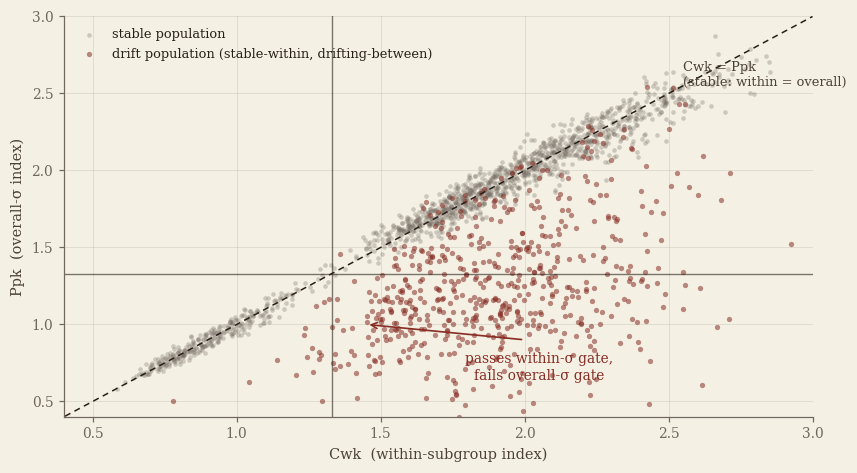

In [7]:
# Fig 1 -- Cwk vs Ppk scatter: the off-diagonal drift cloud IS the story
fig, ax = plt.subplots(figsize=(8, 4.4))
other = summary[summary.population != "drift"]
drift = summary[summary.population == "drift"]
ax.scatter(other.cwk, other.ppk, s=9, color=INK_FAINT, alpha=.30, linewidths=0,
           label="stable population")
ax.scatter(drift.cwk, drift.ppk, s=12, color=RUBRIC, alpha=.55, linewidths=0,
           label="drift population (stable-within, drifting-between)")
lim = 3.0
ax.plot([0, lim], [0, lim], color=INK, lw=1, ls=(0, (4, 3)))               # y = x
ax.axhline(GATE, color=INK, lw=.9, alpha=.6); ax.axvline(GATE, color=INK, lw=.9, alpha=.6)
ax.annotate("Cwk = Ppk\n(stable: within = overall)", (2.55, 2.62), fontsize=8.5,
            color=INK_SOFT, ha="left", va="center")
ax.annotate("passes within-σ gate,\nfails overall-σ gate", (2.05, 0.72), fontsize=9,
            color=RUBRIC, ha="center", va="center")
ax.annotate("", xy=(1.45, 1.0), xytext=(2.0, 0.9),
            arrowprops=dict(arrowstyle="->", color=RUBRIC, lw=1.1))
ax.set_xlim(0.4, lim); ax.set_ylim(0.4, lim)
ax.set_xlabel("Cwk  (within-subgroup index)"); ax.set_ylabel("Ppk  (overall-σ index)")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout(); fig.savefig(FIGS / "spc-fig1.svg"); plt.show()

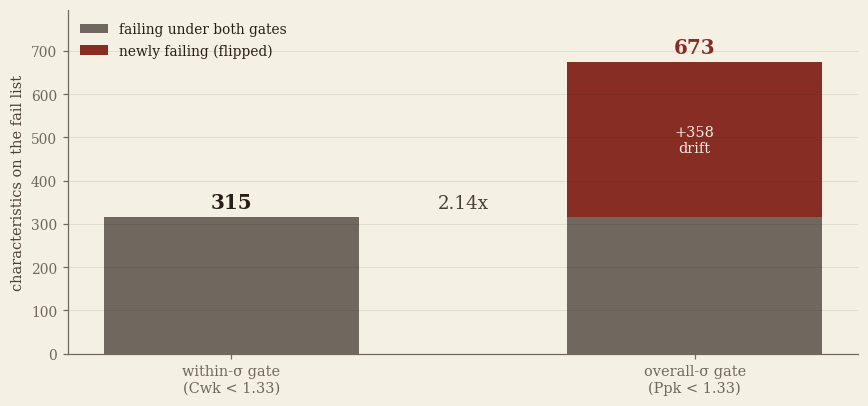

In [8]:
# Fig 2 -- the fail list: within-sigma gate vs overall-sigma gate (the doubling)
new_fail = o_fail - w_fail
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(0, w_fail, width=.55, color=INK_FAINT)
ax.bar(1, w_fail, width=.55, color=INK_FAINT, label="failing under both gates")
ax.bar(1, new_fail, width=.55, bottom=w_fail, color=RUBRIC, label="newly failing (flipped)")
ax.text(0, w_fail + 12, f"{w_fail}", ha="center", va="bottom", fontsize=13, color=INK, fontweight="bold")
ax.text(1, o_fail + 12, f"{o_fail}", ha="center", va="bottom", fontsize=13, color=RUBRIC, fontweight="bold")
ax.text(1, w_fail + new_fail/2, f"+{new_fail}\ndrift", ha="center", va="center",
        fontsize=9.5, color=PAPER)
ax.annotate(f"{ratio:.2f}x", (0.5, max(w_fail, o_fail)*0.5), fontsize=12, color=INK_SOFT, ha="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(["within-σ gate\n(Cwk < 1.33)",
                                            "overall-σ gate\n(Ppk < 1.33)"], fontsize=9.5)
ax.set_ylabel("characteristics on the fail list")
ax.set_ylim(0, o_fail * 1.18)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIGS / "spc-fig2.svg"); plt.show()

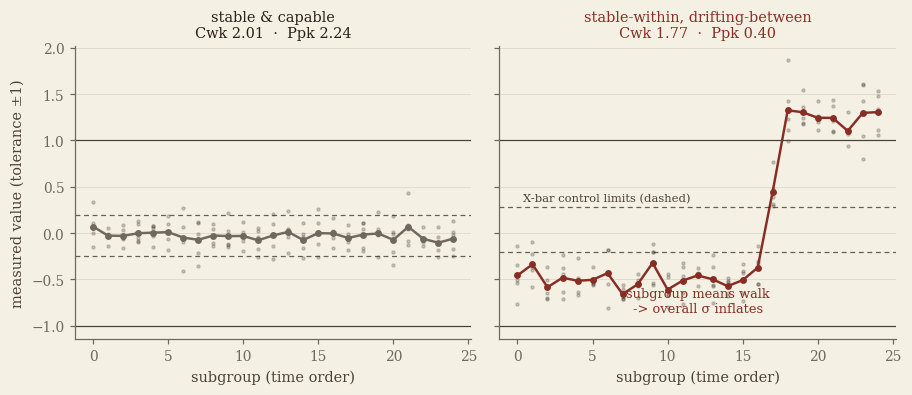

In [9]:
# Fig 3 -- one stable vs one drifting characteristic: within-spread vs between-drift
stable_ex = cap[(cap.population == "capable") & (cap.stable)
                & (cap.cwk.between(row.cwk-0.25, row.cwk+0.25))].sort_values("ppk").index[-1]
pair = [(stable_ex, "stable & capable", INK_FAINT), (ex, "stable-within, drifting-between", RUBRIC)]
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.7), sharey=True)
for axp, (cid, title, col) in zip(axes, pair):
    g = df[df.char_id == cid]
    m = g.pivot_table(index="subgroup", columns="reading_idx", values="value").values
    xbar = m.mean(1); xbb = m.mean(); Rbar = (m.max(1)-m.min(1)).mean()
    sub = np.arange(len(xbar))
    for k in sub:
        axp.plot([k]*m.shape[1], m[k], ".", color=INK, alpha=.20, ms=4)  # raw readings
    axp.plot(sub, xbar, "-", color=col, lw=1.6, marker="o", ms=3.5, label="subgroup mean")
    axp.axhline(xbb + A2*Rbar, color=INK, lw=.8, ls=(0, (4, 3)), alpha=.7)
    axp.axhline(xbb - A2*Rbar, color=INK, lw=.8, ls=(0, (4, 3)), alpha=.7)
    axp.axhline(USL, color=INK_SOFT, lw=.8); axp.axhline(LSL, color=INK_SOFT, lw=.8)
    cwk_i, ppk_i = cap.loc[cid, "cwk"], cap.loc[cid, "ppk"]
    axp.set_title(f"{title}\nCwk {cwk_i:.2f}  ·  Ppk {ppk_i:.2f}", fontsize=9.5,
                  color=col if col == RUBRIC else INK)
    axp.set_xlabel("subgroup (time order)")
    axp.grid(axis="x", visible=False)
axes[0].set_ylabel("measured value (tolerance ±1)")
axes[1].annotate("subgroup means walk\n-> overall σ inflates", (12, LSL+0.15),
                 fontsize=8.5, color=RUBRIC, ha="center")
axes[1].annotate("X-bar control limits (dashed)", (0.4, cap.loc[ex,"xbb"]+A2*cap.loc[ex,"Rbar"]+0.04),
                 fontsize=7.5, color=INK_SOFT, va="bottom")
fig.tight_layout(); fig.savefig(FIGS / "spc-fig3.svg"); plt.show()

## 6 · Autocorrelation sensitivity — when the within index lies

The flip study above assumes **i.i.d. readings inside each subgroup**. On real lines that is not
always true: consecutive measurements in the same subgroup can be serially correlated (tool
warm-up, shared fixture, sampling cadence). AR(1) correlation φ inside a subgroup **does not change
the physical spread the customer sees**, but it **does** shrink the within-subgroup range R̄ — so
R̄/d₂ underestimates σ within and **inflates Cwk** while Ppk (overall σ) barely moves.

Below we hold the process stable and capable (σ within ≈ 0.17) and sweep φ from 0 to 0.8 across
400 Monte Carlo replicates per level. Fig. 4 plots median Cwk vs median Ppk; the committed
extension script is `../scripts/spc_rebase_sensitivity.py`.

## 7 · Gate operating curve — how much drift before the flip?

The headline 2.14× jump comes from one committed generator with a fixed drift scale. A separate
question is **operating-characteristic**: for a pure drift population (tight subgroups, walking
means), what fraction fails Ppk — and what fraction *flips* (pass Cwk, fail Ppk) — as the
between-subgroup walk scale **sb** increases?

Fig. 5 sweeps sb from 0.06 to 0.40 on 250 replicates per grid point. The shaded band marks the sb
range baked into `generate_spc_synthetic.py` (~0.16–0.34). Both the overall-fail and flip curves
cross 50% near **sb ≈ 0.22**: mild between-subgroup drift is enough to hide behind a within gate.

## Limitations

- **This is a simulated dataset**, not a production export. It is engineered to reproduce the
  *phenomenon* — a drift population that is Cwk-good and Ppk-bad — at reduced scale (~2,000 vs
  ~15,000 characteristics). The generator and seed are committed; the numbers reproduce exactly,
  but they are illustrative, not measurements of any real process.
- **The 1.33 gate is a convention**, not a law. A different acceptance target shifts both fail
  counts; the *ratio* between gates is the durable finding, not the absolute counts.
- **One stability test.** Stability here is a single X-bar mean test (A₂R̄). Production SPC layers
  additional run rules; a fuller ruleset would flag some "stable" characteristics too.
- **Normal-ish data.** The simulation uses Gaussian within-subgroup noise. Real characteristics
  include one-sided tolerances and non-normal shapes where the AIAG & VDA manual prescribes
  quantile-based indices — out of scope here.
- **i.i.d. within subgroups in the main CSV.** The autocorrelation sweep (Fig. 4) is a separate
  Monte Carlo; the committed 2,000-characteristic dataset uses independent within-subgroup readings.

## Verdict — more red, and it is the honest number

**The fail list roughly doubling was the correct answer.** The within-σ index (Cwk) asks whether
each process *could* be capable if it held still; the overall-σ index (Ppk) asks what the customer
*receives* across the whole run. A classification gate that runs on the within index quietly
passes every characteristic whose subgroups are tight but whose mean drifts — precisely the
variation a customer experiences. Rebasing the gate onto the overall index surfaced that hidden
population, and the fail list grew ~2×.

The math was never wrong. The *question the number answered* was wrong for the decision it was
driving. Fixing which σ the gate sees — not the arithmetic — is what made the capability report
tell the customer's truth.

In [10]:
# machine-readable results consumed by the case-study page (docs/spc-capability-rebase.html)
results = {
  "production_scale": 15000,
  "n_char": int(n_char),
  "n_subgroups": int(K),
  "n_per_subgroup": int(N),
  "n_measurements": int(len(df)),
  "gate": GATE,
  "pop_mix": summary.population.value_counts().to_dict(),
  "within_fail": w_fail,
  "within_fail_pct": round(w_fail / n_char * 100, 1),
  "overall_fail": o_fail,
  "overall_fail_pct": round(o_fail / n_char * 100, 1),
  "ratio": round(ratio, 2),
  "n_flipped": int(n_flip),
  "flipped_pct_of_passers": round(pct_flip_of_passers, 1),
  "flip_drift_share_pct": round(float((flip.population == "drift").mean() * 100), 0),
  "drift_cwk_median": round(float(summary[summary.population=='drift'].cwk.median()), 2),
  "drift_ppk_median": round(float(summary[summary.population=='drift'].ppk.median()), 2),
  "drift_detected_unstable_pct": round(float((1 - summary[summary.population=='drift'].stable.mean()) * 100), 0),
  "prod_within_fail": 2051,
  "prod_overall_fail": 4094,
  "example_stable_id": int(stable_ex),
  "example_drift_id": int(ex),
  "example_stable_cwk": round(float(cap.loc[stable_ex, "cwk"]), 2),
  "example_stable_ppk": round(float(cap.loc[stable_ex, "ppk"]), 2),
  "example_drift_cwk": round(float(cap.loc[ex, "cwk"]), 2),
  "example_drift_ppk": round(float(cap.loc[ex, "ppk"]), 2),
}
pathlib.Path("../data/spc_results.json").write_text(json.dumps(results, indent=2) + "\n")

import subprocess, sys
subprocess.run([sys.executable, "../scripts/spc_rebase_sensitivity.py"], check=True)
results = json.loads(pathlib.Path("../data/spc_results.json").read_text())
results

{'production_scale': 15000,
 'n_char': 2000,
 'n_subgroups': 25,
 'n_per_subgroup': 5,
 'n_measurements': 250000,
 'gate': 1.33,
 'pop_mix': {'capable': 1100, 'drift': 600, 'incapable': 300},
 'within_fail': 315,
 'within_fail_pct': 15.8,
 'overall_fail': 673,
 'overall_fail_pct': 33.7,
 'ratio': 2.14,
 'n_flipped': 361,
 'flipped_pct_of_passers': np.float64(21.4),
 'flip_drift_share_pct': 100.0,
 'drift_cwk_median': 1.9,
 'drift_ppk_median': 1.2,
 'drift_detected_unstable_pct': 90.0,
 'prod_within_fail': 2051,
 'prod_overall_fail': 4094,
 'example_stable_id': 606,
 'example_drift_id': 208,
 'example_stable_cwk': 2.01,
 'example_stable_ppk': 2.24,
 'example_drift_cwk': 1.77,
 'example_drift_ppk': 0.4}

In [ ]:
# Figs 4–5 (generated by spc_rebase_sensitivity.py in the cell above)
from IPython.display import SVG, display
for name in ("spc-fig4.svg", "spc-fig5.svg"):
    display(SVG(pathlib.Path(f"../docs/figures/{name}").read_text()))